In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

base = Path("..") / "pass_decision"

SEEDS = [0, 42, 1337, 2026]
# SEEDS = [0, 42, 337]

hs_ws_df = pd.concat(
    [
        pd.read_csv(base / f"hs_ws_runs_seed{seed}" / "decodability_results.csv").assign(seed=seed)
        for seed in SEEDS
    ],
    ignore_index=True,
)

noise_df = pd.concat(
    [
        pd.read_csv(base / f"noise_runs_seed{seed}" / "decodability_results.csv").assign(seed=seed)
        for seed in SEEDS
    ],
    ignore_index=True,
)

msg_hs_ws_df = pd.concat(
    [
        pd.read_csv(base / f"hs_ws_runs_seed{seed}" / "message_decodability_results.csv").assign(seed=seed)
        for seed in SEEDS
    ],
    ignore_index=True,
)
msg_hs_ws_df["representation"] = msg_hs_ws_df["representation"].str.strip()

# msg_noise_paths = [
#     base / f"noise_runs_seed{seed}" / "message_decodability_results.csv"
#     for seed in SEEDS
#     if (base / f"noise_runs_seed{seed}" / "message_decodability_results.csv").exists()
# ]
# msg_noise_df = pd.concat(
#     [pd.read_csv(p).assign(seed=int(p.parent.name.replace("noise_runs_seed", ""))) for p in msg_noise_paths],
#     ignore_index=True,
# )
# if not msg_noise_df.empty:
#     msg_noise_df["representation"] = msg_noise_df["representation"].str.strip()


In [37]:
# # P vs D decodability: 4 cols (metric) × 2 rows (truth input | cumsum targets)

# from matplotlib.lines import Line2D

# metric_columns = {
#     "score_continuous": "Continuous",
#     "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
#     "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
#     "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
# }

# ws_values = sorted(hs_ws_df["ws"].unique())
# hidden_sizes = sorted(hs_ws_df["hidden_size"].unique())
# ws_colors = {ws: f"C{i}" for i, ws in enumerate(ws_values)}

# # Visual-only label swap: ws=1.0 <-> ws=2.25
# def display_ws(ws):
#     return {1.0: 2.25, 2.25: 1.0}.get(ws, ws)

# seeds = sorted(hs_ws_df["seed"].unique())
# noise_p = hs_ws_df["noise_p"].iloc[0]
# noise_d = hs_ws_df["noise_d"].iloc[0]

# TITLE_FS = 18
# LABEL_FS = 16
# TICK_FS = 14
# LEGEND_FS = 14
# SUPTITLE_FS = 20

# row_specs = [
#     {
#         "targets": ["inp"],
#         "markers": {"inp": "o"},
#         "ylabel": "truth input",
#     },
#     {
#         "targets": ["cumsum", "sign_cumsum"],
#         "markers": {"cumsum": "o", "sign_cumsum": "s"},
#         "ylabel": "cumsum / sign(cumsum)",
#     },
# ]

# fig, axes = plt.subplots(2, 4, figsize=(24, 10), dpi=400, sharex=True, sharey=False)

# for row, spec in enumerate(row_specs):
#     for col, (metric, metric_label) in enumerate(metric_columns.items()):
#         ax = axes[row, col]
#         for target in spec["targets"]:
#             sub = hs_ws_df[hs_ws_df["target"] == target]
#             marker = spec["markers"][target]
#             for ws in ws_values:
#                 color = ws_colors[ws]
#                 ws_sub = sub[sub["ws"] == ws]
#                 for area, linestyle in [("P", "-"), ("D", ":")]:
#                     area_sub = ws_sub[ws_sub["decode_from"] == area]
#                     g = area_sub.groupby("hidden_size")[metric]
#                     mean = g.mean().sort_index()
#                     std = g.std().fillna(0).sort_index()
#                     show_ws_legend = (
#                         row == 0 and col == 0 and area == "P" and target == spec["targets"][0]
#                     )
#                     ax.plot(
#                         mean.index,
#                         mean.values,
#                         marker=marker,
#                         linestyle=linestyle,
#                         color=color,
#                         label=f"ws={display_ws(ws)}" if show_ws_legend else "_nolegend_",
#                     )
#                     ax.fill_between(
#                         mean.index,
#                         mean.values - std.values,
#                         mean.values + std.values,
#                         color=color,
#                         alpha=0.12 if area == "P" else 0.06,
#                     )

#         if row == 0:
#             ax.set_title(metric_label, fontsize=TITLE_FS)
#         if row == 1:
#             ax.set_xlabel("Hidden size", fontsize=LABEL_FS)
#         if col == 0:
#             ax.set_ylabel(spec["ylabel"] + "\n" + r"$R^2$", fontsize=LABEL_FS)
#         ax.set_xticks(hidden_sizes)
#         ax.set_xticklabels([str(h) for h in hidden_sizes], rotation=45, ha="right", fontsize=TICK_FS)
#         ax.tick_params(axis="both", labelsize=TICK_FS)

# ws_handles, _ = axes[0, 0].get_legend_handles_labels()
# style_handles = [
#     Line2D([0], [0], color="k", linestyle="-", label="P"),
#     Line2D([0], [0], color="k", linestyle=":", label="D"),
#     Line2D([0], [0], color="k", marker="o", linestyle="None", label="cumsum"),
#     Line2D([0], [0], color="k", marker="s", linestyle="None", label="sign(cumsum)"),
# ]
# axes[0, 0].legend(handles=ws_handles + style_handles, fontsize=LEGEND_FS, loc="best")

# fig.suptitle(
#     f"Pass decision decodability "
#     f"(noise_p={noise_p}, noise_d={noise_d}; mean+/-std over seeds [0, 42, 1337, 2026])",
#     fontsize=SUPTITLE_FS,
# )
# fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.show()


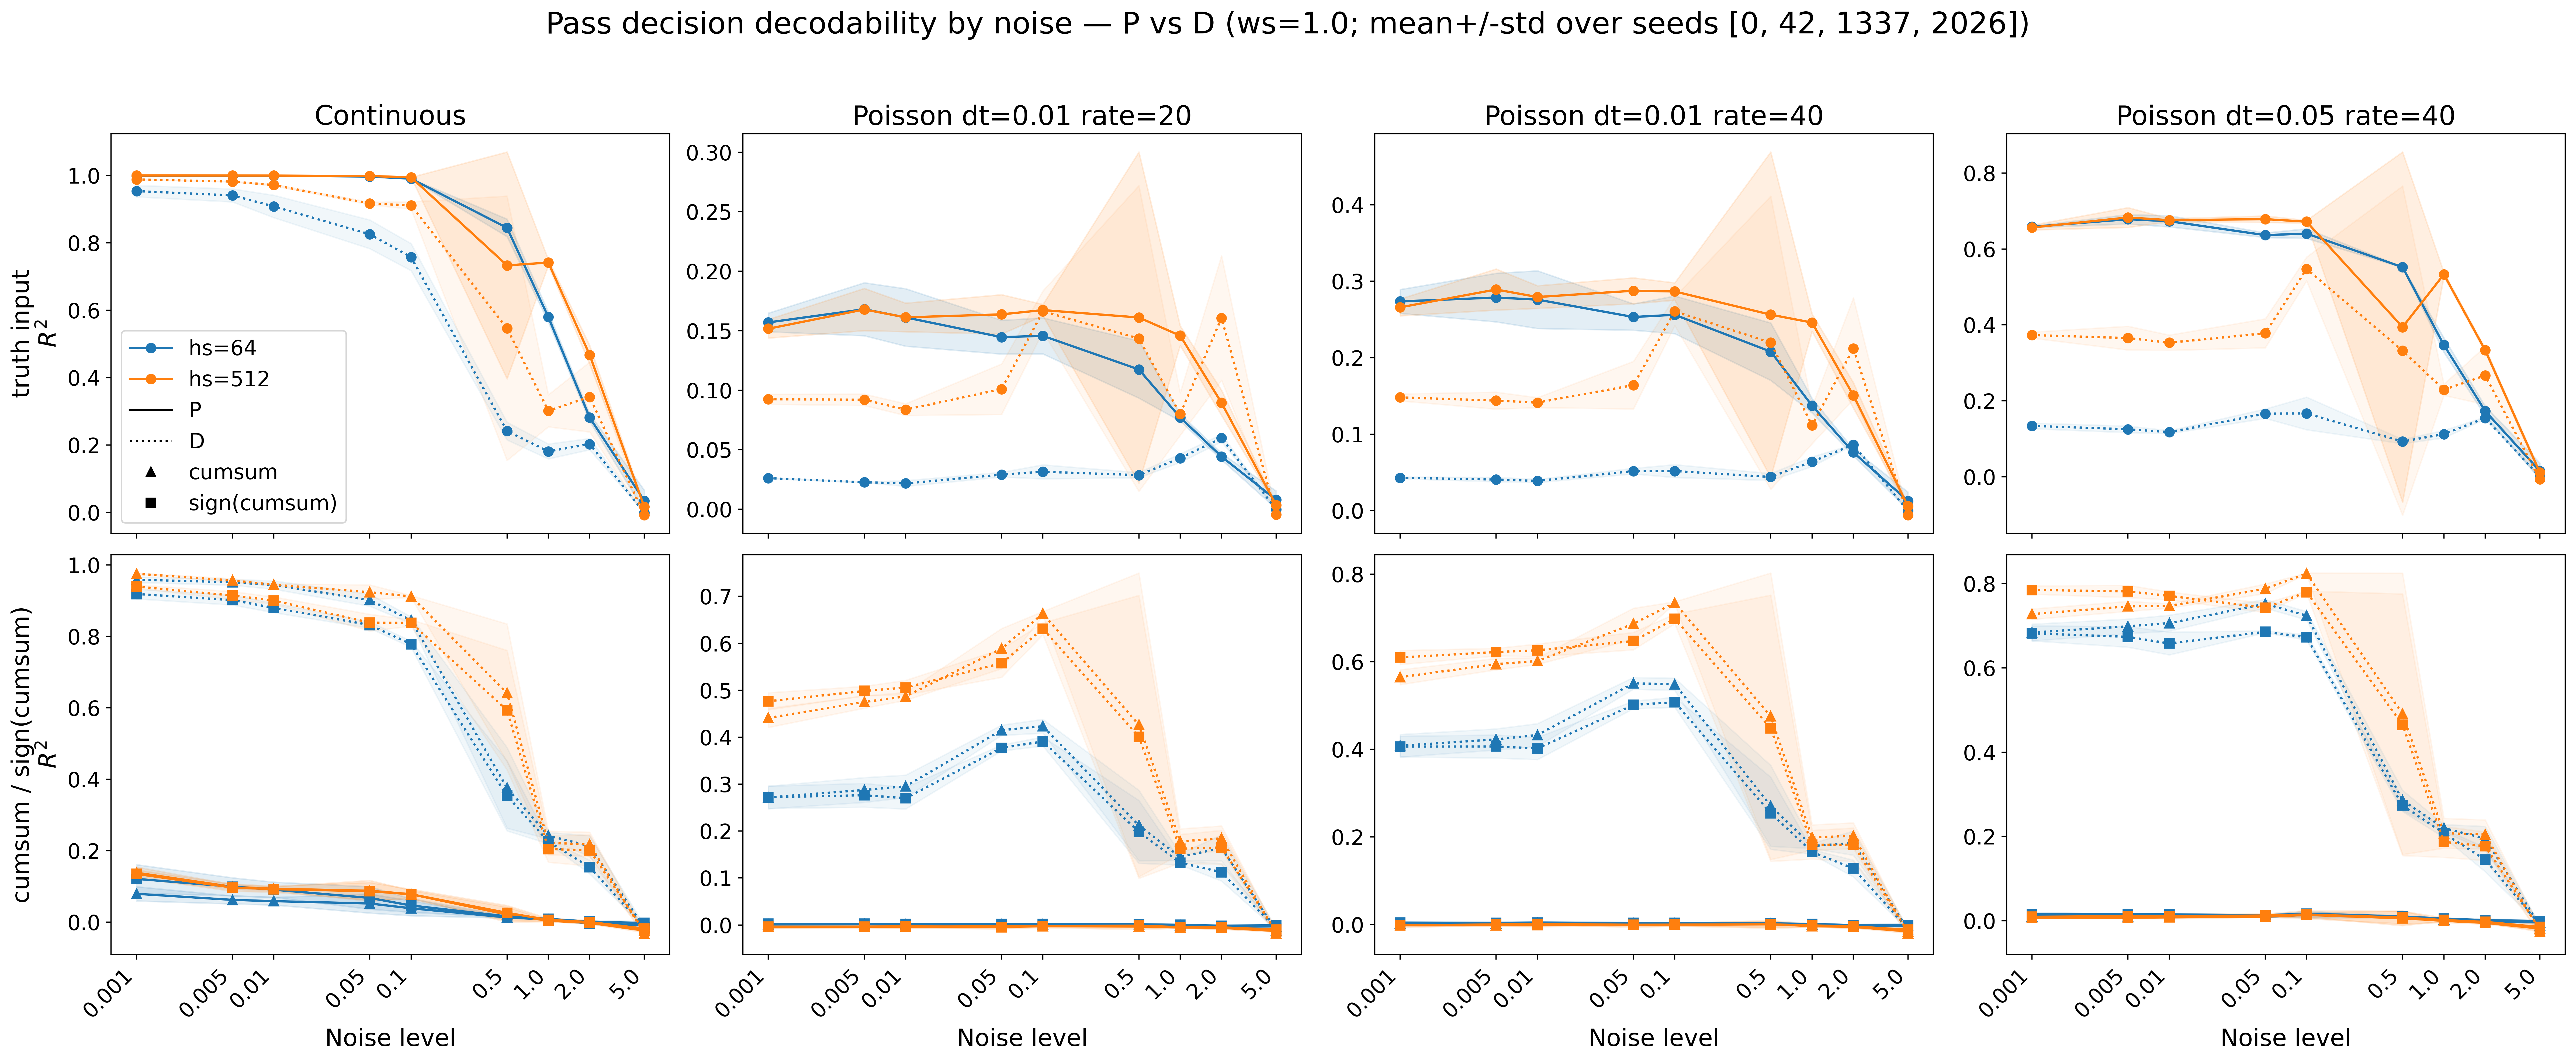

In [44]:
# P vs D decodability by noise: 4 cols (metric) × 2 rows (truth input | cumsum targets)

from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

# Prefer long-form CSVs that include target / multi-area rows
plot_df = noise_df.dropna(subset=["target"]).copy() if "target" in noise_df.columns else noise_df.copy()
if "target" not in plot_df.columns:
    raise ValueError(
        "noise_df is missing 'target' column. Recompute with pd_compute_decodability.py "
        "for noise_runs_seed* folders."
    )

noise_levels = sorted(plot_df["noise_p"].unique())
hidden_sizes = [hs for hs in [64, 512] if hs in set(plot_df["hidden_size"].unique())]
hs_colors = {hs: f"C{i}" for i, hs in enumerate(hidden_sizes)}
plot_df = plot_df[plot_df["hidden_size"].isin(hidden_sizes)]

ws = plot_df["ws"].iloc[0]
seeds = sorted(plot_df["seed"].unique())

TITLE_FS = 18
LABEL_FS = 16
TICK_FS = 14
LEGEND_FS = 14
SUPTITLE_FS = 20

row_specs = [
    {
        "targets": ["inp"],
        "markers": {"inp": "o"},
        "ylabel": "truth input",
    },
    {
        "targets": ["cumsum", "sign_cumsum"],
        "markers": {"cumsum": "^", "sign_cumsum": "s"},
        "ylabel": "cumsum / sign(cumsum)",
    },
]

fig, axes = plt.subplots(2, 4, figsize=(24, 10), dpi=400, sharex=True, sharey=False)

for row, spec in enumerate(row_specs):
    for col, (metric, metric_label) in enumerate(metric_columns.items()):
        ax = axes[row, col]
        for target in spec["targets"]:
            sub = plot_df[plot_df["target"] == target]
            marker = spec["markers"][target]
            for hs in hidden_sizes:
                color = hs_colors[hs]
                hs_sub = sub[sub["hidden_size"] == hs]
                for area, linestyle in [("P", "-"), ("D", ":")]:
                    area_sub = hs_sub[hs_sub["decode_from"] == area]
                    g = area_sub.groupby("noise_p")[metric]
                    mean = g.mean().sort_index()
                    std = g.std().fillna(0).sort_index()
                    show_hs_legend = (
                        row == 0 and col == 0 and area == "P" and target == spec["targets"][0]
                    )
                    ax.plot(
                        mean.index,
                        mean.values,
                        marker=marker,
                        linestyle=linestyle,
                        color=color,
                        label=f"hs={hs}" if show_hs_legend else "_nolegend_",
                    )
                    ax.fill_between(
                        mean.index,
                        mean.values - std.values,
                        mean.values + std.values,
                        color=color,
                        alpha=0.12 if area == "P" else 0.06,
                    )

        ax.set_xscale("log")
        ax.xaxis.set_major_locator(FixedLocator(noise_levels))
        ax.xaxis.set_minor_locator(NullLocator())
        ax.set_xticklabels([str(n) for n in noise_levels], rotation=45, ha="right", fontsize=TICK_FS)
        ax.tick_params(axis="both", labelsize=TICK_FS)

        if row == 0:
            ax.set_title(metric_label, fontsize=TITLE_FS)
        if row == 1:
            ax.set_xlabel("Noise level", fontsize=LABEL_FS)
        if col == 0:
            ax.set_ylabel(spec["ylabel"] + "\n" + r"$R^2$", fontsize=LABEL_FS)

hs_handles, _ = axes[0, 0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="P"),
    Line2D([0], [0], color="k", linestyle=":", label="D"),
    Line2D([0], [0], color="k", marker="^", linestyle="None", label="cumsum"),
    Line2D([0], [0], color="k", marker="s", linestyle="None", label="sign(cumsum)"),
]
axes[0, 0].legend(handles=hs_handles + style_handles, fontsize=LEGEND_FS, loc="best")

fig.suptitle(
    f"Pass decision decodability by noise — P vs D "
    f"(ws={ws}; mean+/-std over seeds [0, 42, 1337, 2026])",
    fontsize=SUPTITLE_FS,
)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


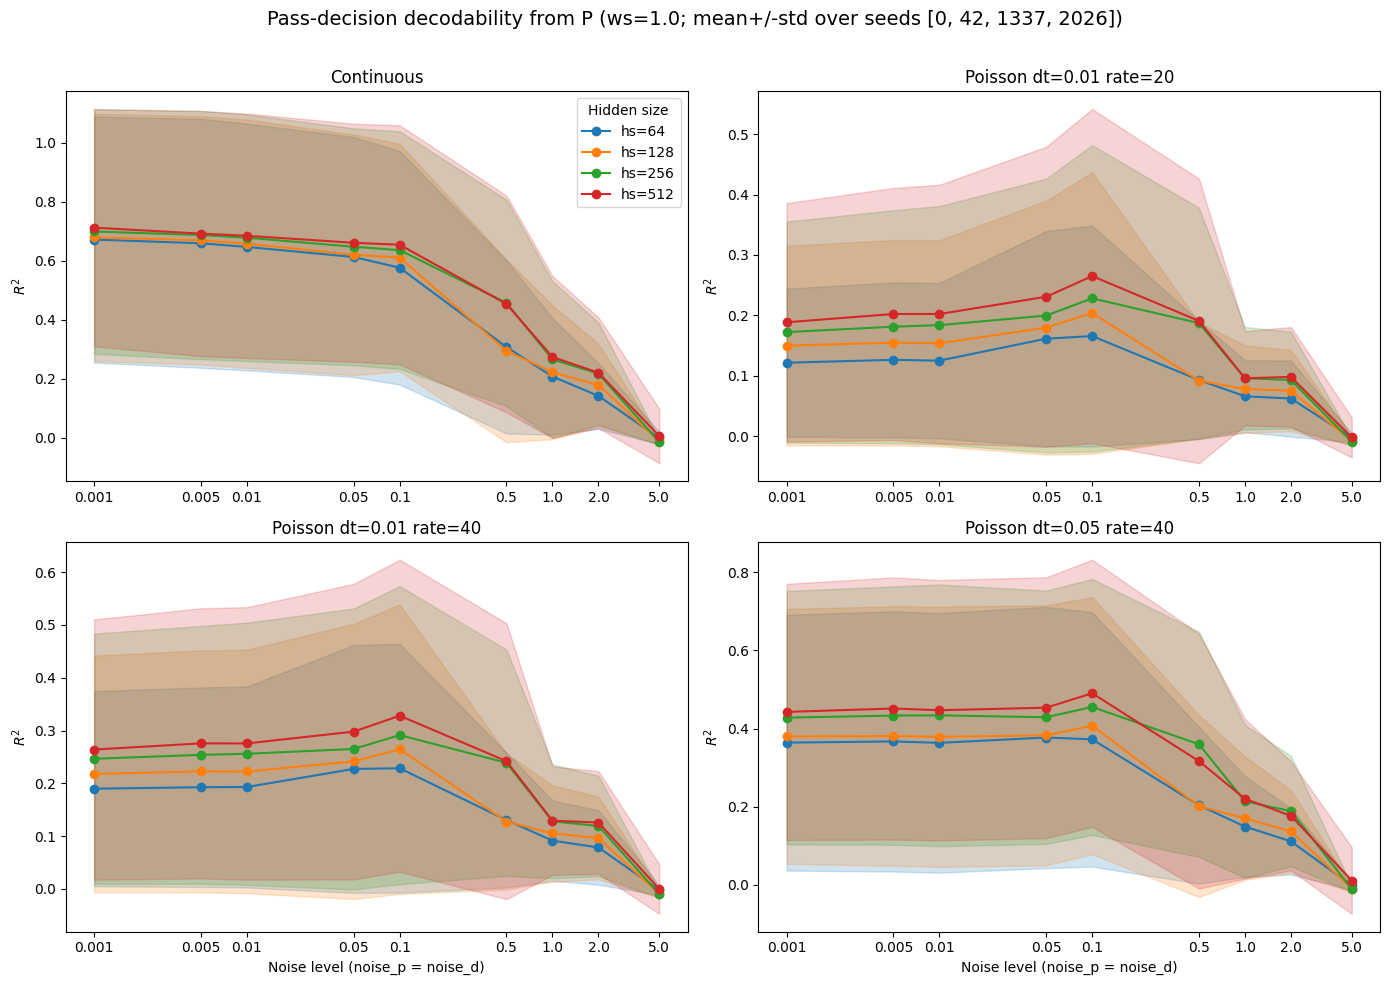

In [39]:
# Decodability by noise level (decode from P)
# Mean +/- std across seeds; separate lines for h256 vs h512

from matplotlib.ticker import FixedLocator, NullLocator

metric_columns = {
    "score_continuous": "Continuous",
    "score_poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "score_poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "score_poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

noise_levels = sorted(noise_df["noise_p"].unique())
hidden_sizes = sorted(noise_df["hidden_size"].unique())
hs_colors = {hs: f"C{i}" for i, hs in enumerate(hidden_sizes)}

decode_from = noise_df["decode_from"].iloc[0]
ws = noise_df["ws"].iloc[0]
seeds = sorted(noise_df["seed"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (metric, label) in zip(axes, metric_columns.items()):
    for hs in hidden_sizes:
        color = hs_colors[hs]
        subset = noise_df[noise_df["hidden_size"] == hs]
        g = subset.groupby("noise_p")[metric]
        mean = g.mean().sort_index()
        std = g.std().fillna(0).sort_index()
        ax.plot(mean.index, mean.values, marker="o", linestyle="-", color=color, label=f"hs={hs}")
        ax.fill_between(mean.index, mean.values - std.values, mean.values + std.values, color=color, alpha=0.2)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(noise_levels))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([str(n) for n in noise_levels])
    ax.set_ylabel(r"$R^2$")
    ax.set_title(label)
    if ax in (axes[2], axes[3]):
        ax.set_xlabel("Noise level (noise_p = noise_d)")

axes[0].legend(title="Hidden size")
fig.suptitle(
    f"Pass-decision decodability from {decode_from} "
    f"(ws={ws}; mean+/-std over seeds {seeds})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


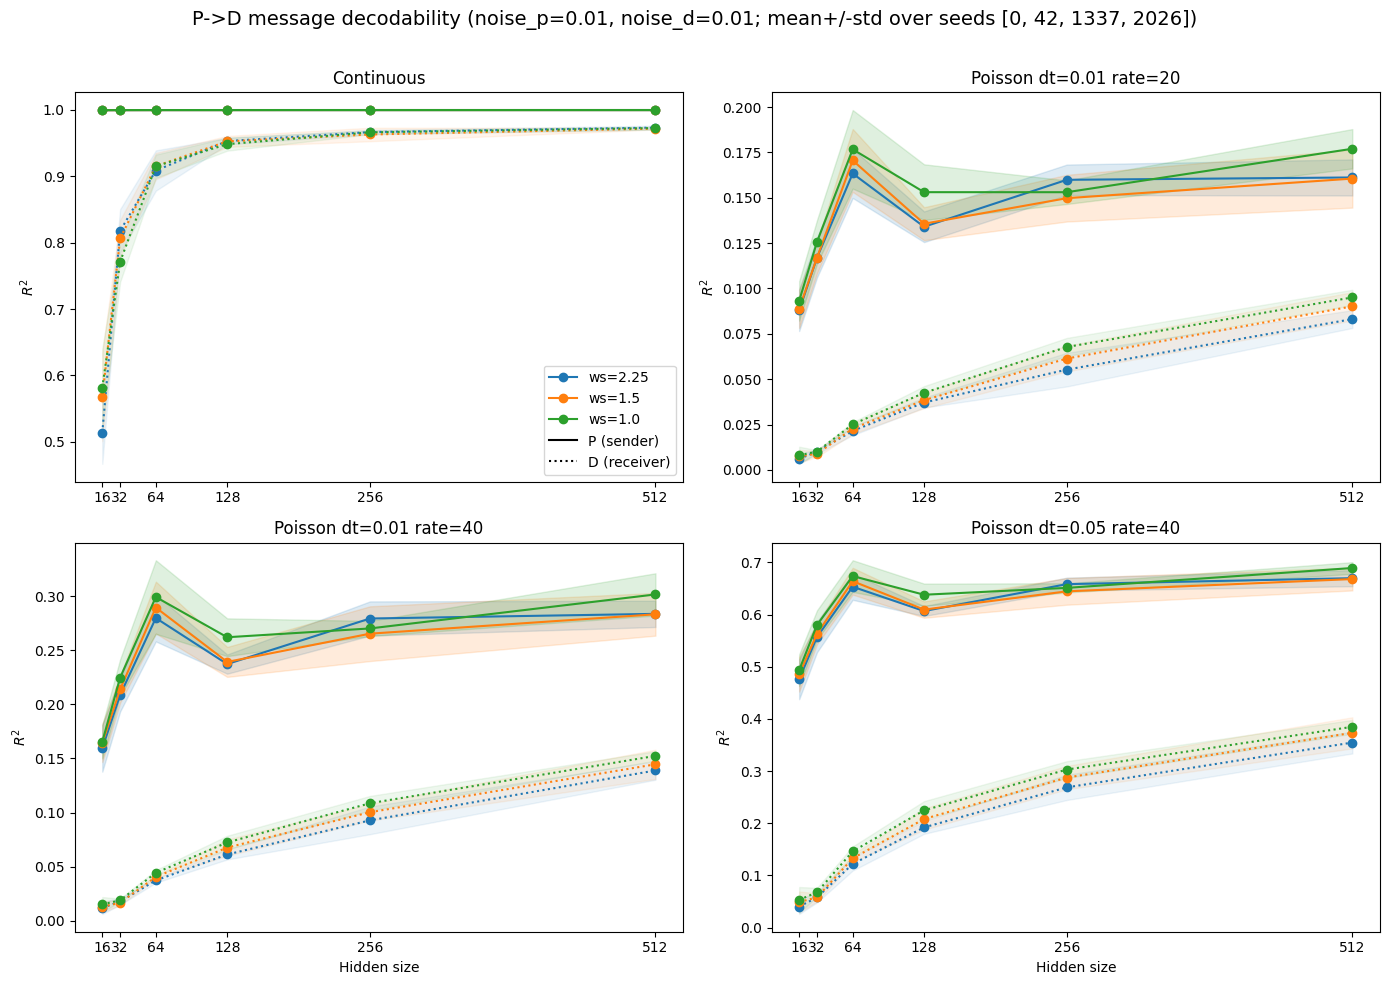

In [40]:
# Message decodability: P vs D by hidden size and weight scale
# Mean +/- std across seeds

from matplotlib.lines import Line2D

representation_columns = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

ws_values = sorted(msg_hs_ws_df["ws"].unique())
hidden_sizes = sorted(msg_hs_ws_df["hidden_size"].unique())
ws_colors = {ws: f"C{i}" for i, ws in enumerate(ws_values)}

# Visual-only label swap: ws=1.0 <-> ws=2.25
def display_ws(ws):
    return {1.0: 2.25, 2.25: 1.0}.get(ws, ws)

noise_p = msg_hs_ws_df["noise_p"].iloc[0]
noise_d = msg_hs_ws_df["noise_d"].iloc[0]
seeds = sorted(msg_hs_ws_df["seed"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rep, label) in zip(axes, representation_columns.items()):
    rep_df = msg_hs_ws_df[msg_hs_ws_df["representation"] == rep]
    for ws in ws_values:
        color = ws_colors[ws]
        subset = rep_df[rep_df["ws"] == ws]
        g_p = subset.groupby("hidden_size")["r2_P"]
        g_d = subset.groupby("hidden_size")["r2_D"]
        mean_p = g_p.mean().sort_index()
        std_p = g_p.std().fillna(0).sort_index()
        mean_d = g_d.mean().sort_index()
        std_d = g_d.std().fillna(0).sort_index()
        ax.plot(mean_p.index, mean_p.values, marker="o", linestyle="-", color=color, label=f"ws={display_ws(ws)}")
        ax.fill_between(mean_p.index, mean_p.values - std_p.values, mean_p.values + std_p.values, color=color, alpha=0.15)
        ax.plot(mean_d.index, mean_d.values, marker="o", linestyle=":", color=color, label="_nolegend_")
        ax.fill_between(mean_d.index, mean_d.values - std_d.values, mean_d.values + std_d.values, color=color, alpha=0.08)
    if ax in (axes[2], axes[3]):
        ax.set_xlabel("Hidden size")
    ax.set_ylabel(r"$R^2$")
    ax.set_title(label)
    ax.set_xticks(hidden_sizes)
    ax.set_xticklabels([str(h) for h in hidden_sizes])

ws_handles, ws_labels = axes[0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="P (sender)"),
    Line2D([0], [0], color="k", linestyle=":", label="D (receiver)"),
]
axes[0].legend(handles=ws_handles + style_handles, labels=ws_labels + ["P (sender)", "D (receiver)"])
fig.suptitle(
    f"P->D message decodability (noise_p={noise_p}, noise_d={noise_d}; mean+/-std over seeds {seeds})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [41]:
# Message decodability: P vs D by noise level
# Mean +/- std across available seeds; separate lines for h256 vs h512

from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, NullLocator

representation_columns = {
    "continuous": "Continuous",
    "poisson_dt0.01_rate20": "Poisson dt=0.01 rate=20",
    "poisson_dt0.01_rate40": "Poisson dt=0.01 rate=40",
    "poisson_dt0.05_rate40": "Poisson dt=0.05 rate=40",
}

noise_levels = sorted(msg_noise_df["noise_p"].unique())
hidden_sizes = sorted(msg_noise_df["hidden_size"].unique())
hs_colors = {hs: f"C{i}" for i, hs in enumerate(hidden_sizes)}
ws = msg_noise_df["ws"].iloc[0]
seeds = sorted(msg_noise_df["seed"].unique())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (rep, label) in zip(axes, representation_columns.items()):
    rep_df = msg_noise_df[msg_noise_df["representation"] == rep]
    for hs in hidden_sizes:
        color = hs_colors[hs]
        subset = rep_df[rep_df["hidden_size"] == hs]
        g_p = subset.groupby("noise_p")["r2_P"]
        g_d = subset.groupby("noise_p")["r2_D"]
        mean_p = g_p.mean().sort_index()
        std_p = g_p.std().fillna(0).sort_index()
        mean_d = g_d.mean().sort_index()
        std_d = g_d.std().fillna(0).sort_index()
        ax.plot(mean_p.index, mean_p.values, marker="o", linestyle="-", color=color, label=f"hs={hs}")
        ax.fill_between(mean_p.index, mean_p.values - std_p.values, mean_p.values + std_p.values, color=color, alpha=0.15)
        ax.plot(mean_d.index, mean_d.values, marker="o", linestyle=":", color=color, label="_nolegend_")
        ax.fill_between(mean_d.index, mean_d.values - std_d.values, mean_d.values + std_d.values, color=color, alpha=0.08)
    ax.set_title(label)
    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(noise_levels))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.set_xticklabels([str(n) for n in noise_levels])
    ax.set_ylabel(r"$R^2$")
    if ax in (axes[2], axes[3]):
        ax.set_xlabel("Noise level (noise_p = noise_d)")

hs_handles, hs_labels = axes[0].get_legend_handles_labels()
style_handles = [
    Line2D([0], [0], color="k", linestyle="-", label="P (sender)"),
    Line2D([0], [0], color="k", linestyle=":", label="D (receiver)"),
]
axes[0].legend(handles=hs_handles + style_handles, labels=hs_labels + ["P (sender)", "D (receiver)"])
fig.suptitle(
    f"P->D message decodability (ws={ws}; mean+/-std over seeds {seeds})",
    fontsize=14,
)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


NameError: name 'msg_noise_df' is not defined

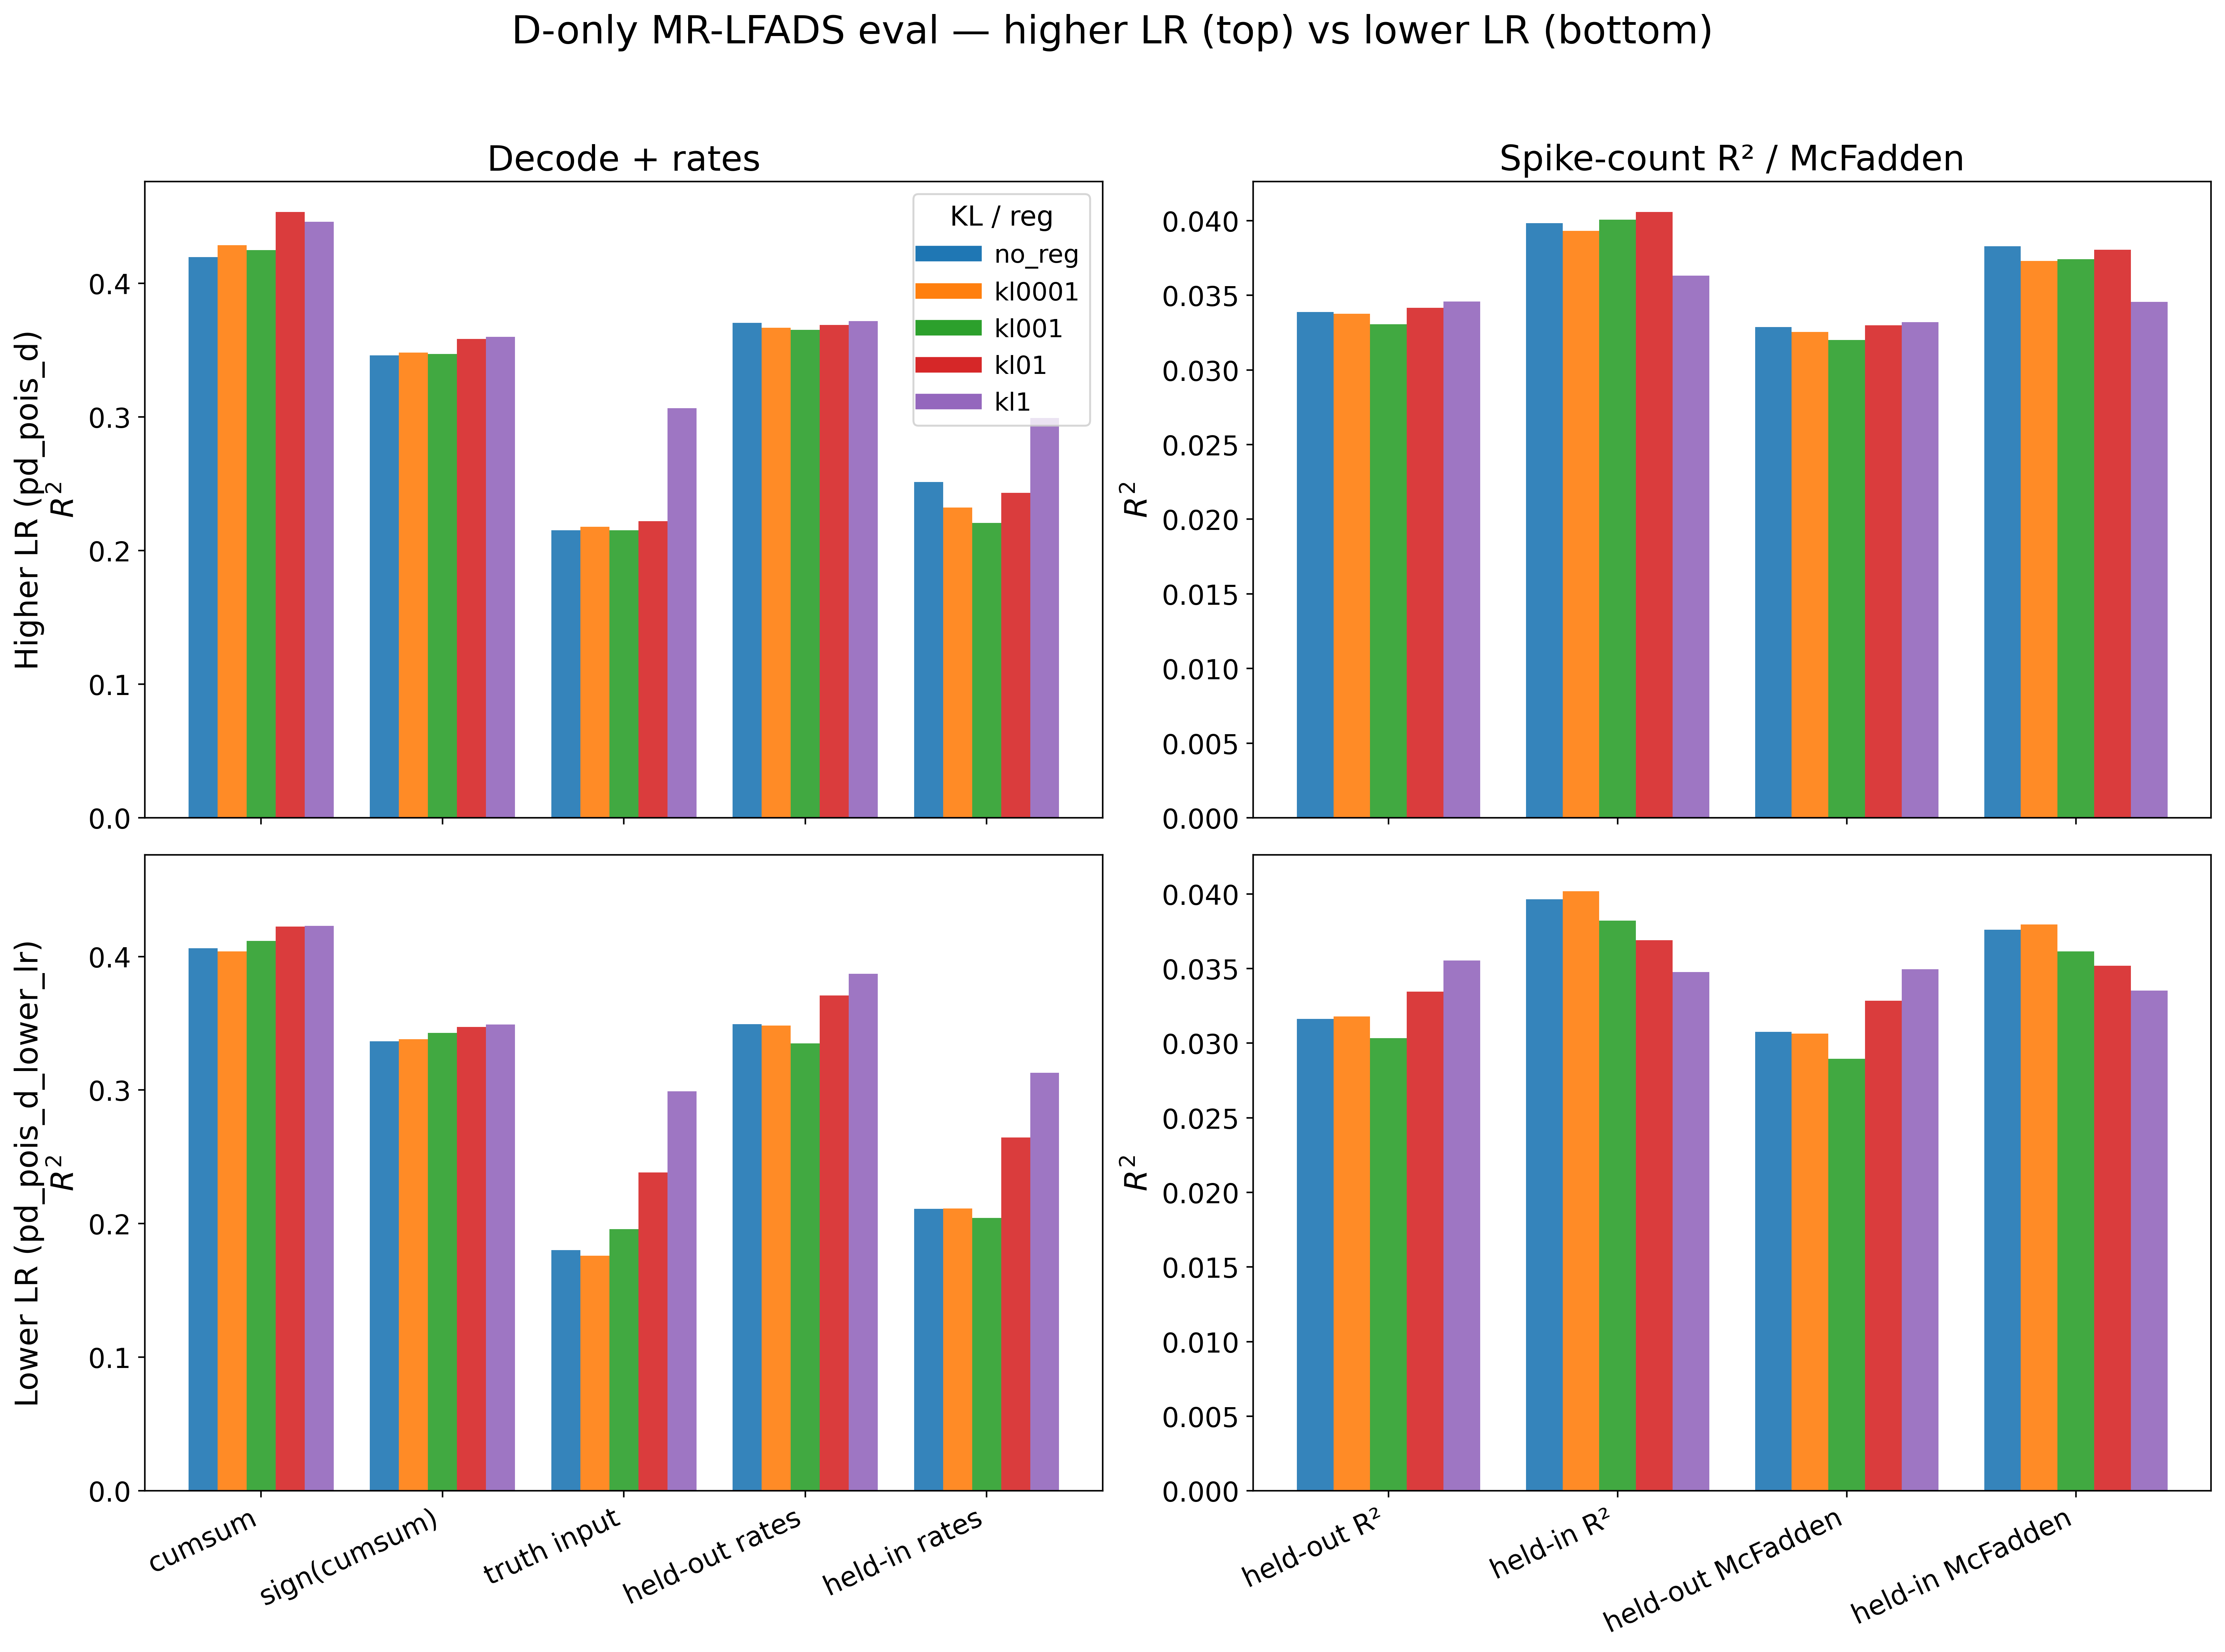

In [19]:
# D-only MR-LFADS: higher LR (top) vs lower LR (bottom)
# Columns: decode+rates | spike-count R²/McFadden

import re

from matplotlib.lines import Line2D
import numpy as np

KL_ORDER = ["no_reg", "kl0001", "kl001", "kl01", "kl1"]
kl_colors = {kl: f"C{i}" for i, kl in enumerate(KL_ORDER)}

metric_groups = [
    (
        "Decode + rates",
        [
            ("cumsum-decode-r2-mean", "cumsum"),
            ("sign_cumsum-decode-r2-mean", "sign(cumsum)"),
            ("truth-inp-decode-r2-mean", "truth input"),
            ("r2-held-out-rates-mean", "held-out rates"),
            ("r2-held-in-rates-mean", "held-in rates"),
        ],
    ),
    (
        "Spike-count R² / McFadden",
        [
            ("r2-held-out-mean", "held-out R²"),
            ("r2-held-in-mean", "held-in R²"),
            ("r2-held-out-mcfadden-mean", "held-out McFadden"),
            ("r2-held-in-mcfadden-mean", "held-in McFadden"),
        ],
    ),
]


def parse_kl(run_name: str) -> str:
    if "no_reg" in run_name:
        return "no_reg"
    m = re.search(r"_(kl\d+)_", run_name)
    return m.group(1) if m else run_name


higher_df = pd.read_csv(Path("..") / "mrlfads-runs" / "pd_pois_d" / "eval_summary.csv")
lower_df = pd.read_csv(Path("..") / "mrlfads-runs" / "pd_pois_d_lower_lr" / "eval_summary.csv")

higher_df["kl"] = higher_df["run"].map(parse_kl)
lower_df["kl"] = lower_df["run"].map(parse_kl)

lr_panels = [
    ("Higher LR (pd_pois_d)", higher_df.set_index("kl").reindex(KL_ORDER)),
    ("Lower LR (pd_pois_d_lower_lr)", lower_df.set_index("kl").reindex(KL_ORDER)),
]

n_kl = len(KL_ORDER)
handles = [Line2D([0], [0], color=kl_colors[kl], lw=8, label=kl) for kl in KL_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=400, sharey="col")

for row, (lr_title, df) in enumerate(lr_panels):
    for col, (group_name, metric_specs) in enumerate(metric_groups):
        ax = axes[row, col]
        n_metrics = len(metric_specs)
        x = np.arange(n_metrics)
        width = 0.8 / n_kl

        for j, kl in enumerate(KL_ORDER):
            vals = [df.loc[kl, col_name] for col_name, _ in metric_specs]
            offset = (j - (n_kl - 1) / 2) * width
            ax.bar(
                x + offset,
                vals,
                width=width,
                color=kl_colors[kl],
                label=kl,
                alpha=0.9,
            )

        if row == 0:
            ax.set_title(group_name, fontsize=18)
        if row == 1:
            ax.set_xticks(x)
            ax.set_xticklabels([lab for _, lab in metric_specs], rotation=25, ha="right", fontsize=14)
        else:
            ax.set_xticks(x)
            ax.set_xticklabels([])

        if col == 0:
            ax.set_ylabel(lr_title + "\n" + r"$R^2$", fontsize=16)
        else:
            ax.set_ylabel(r"$R^2$", fontsize=16)
        ax.tick_params(axis="y", labelsize=14)
        # ax.grid(True, axis="y", alpha=0.25)

axes[0, 0].legend(handles=handles, title="KL / reg", fontsize=13, title_fontsize=14)

fig.suptitle("D-only MR-LFADS eval — higher LR (top) vs lower LR (bottom)", fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


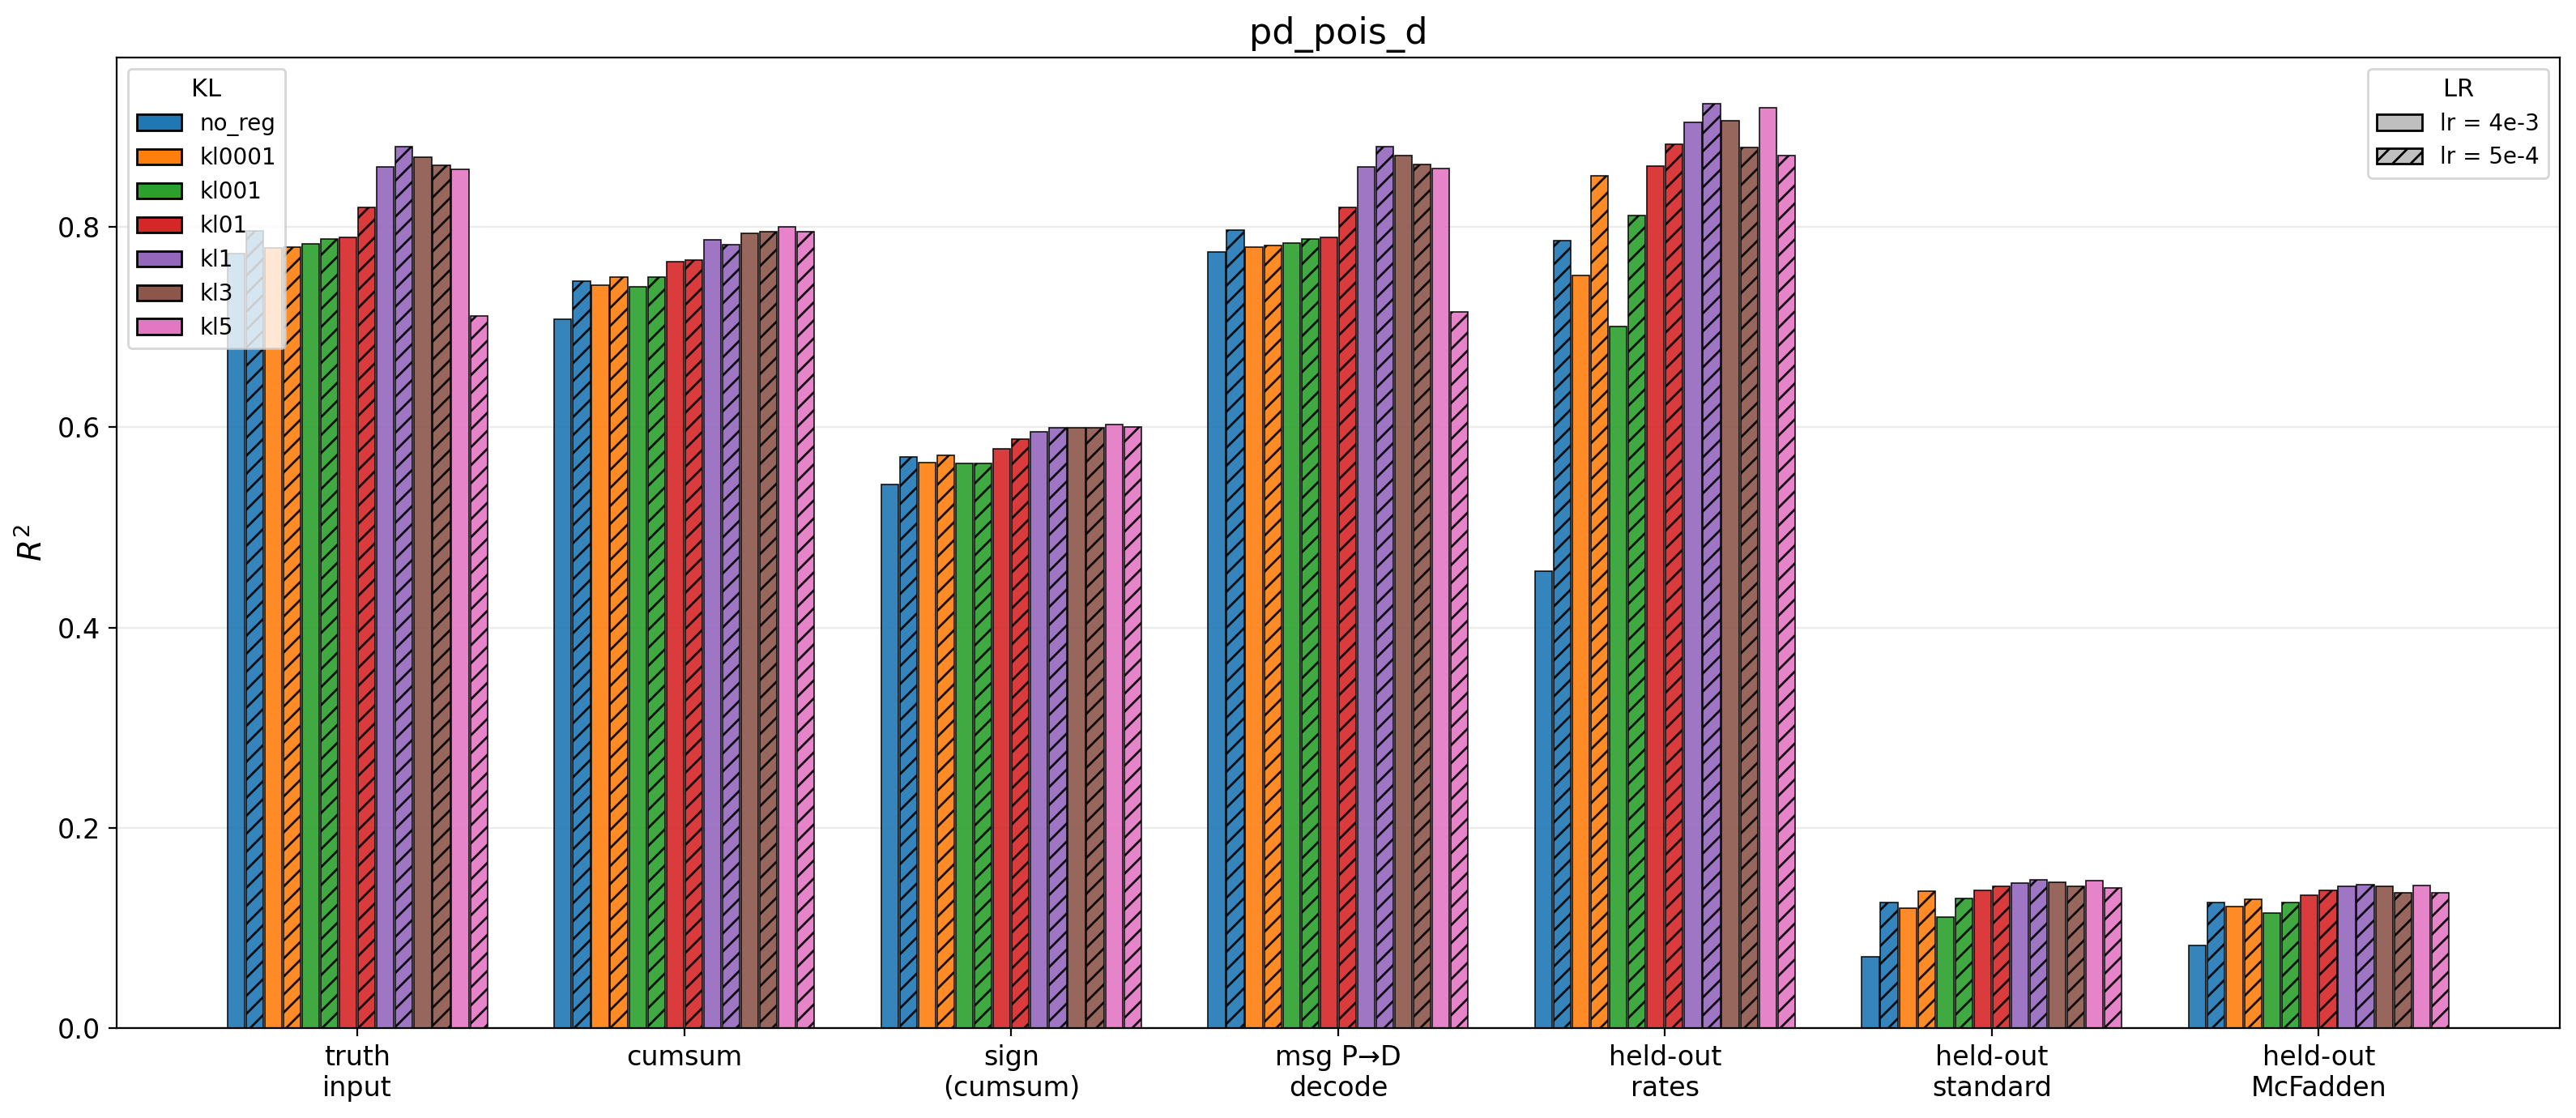

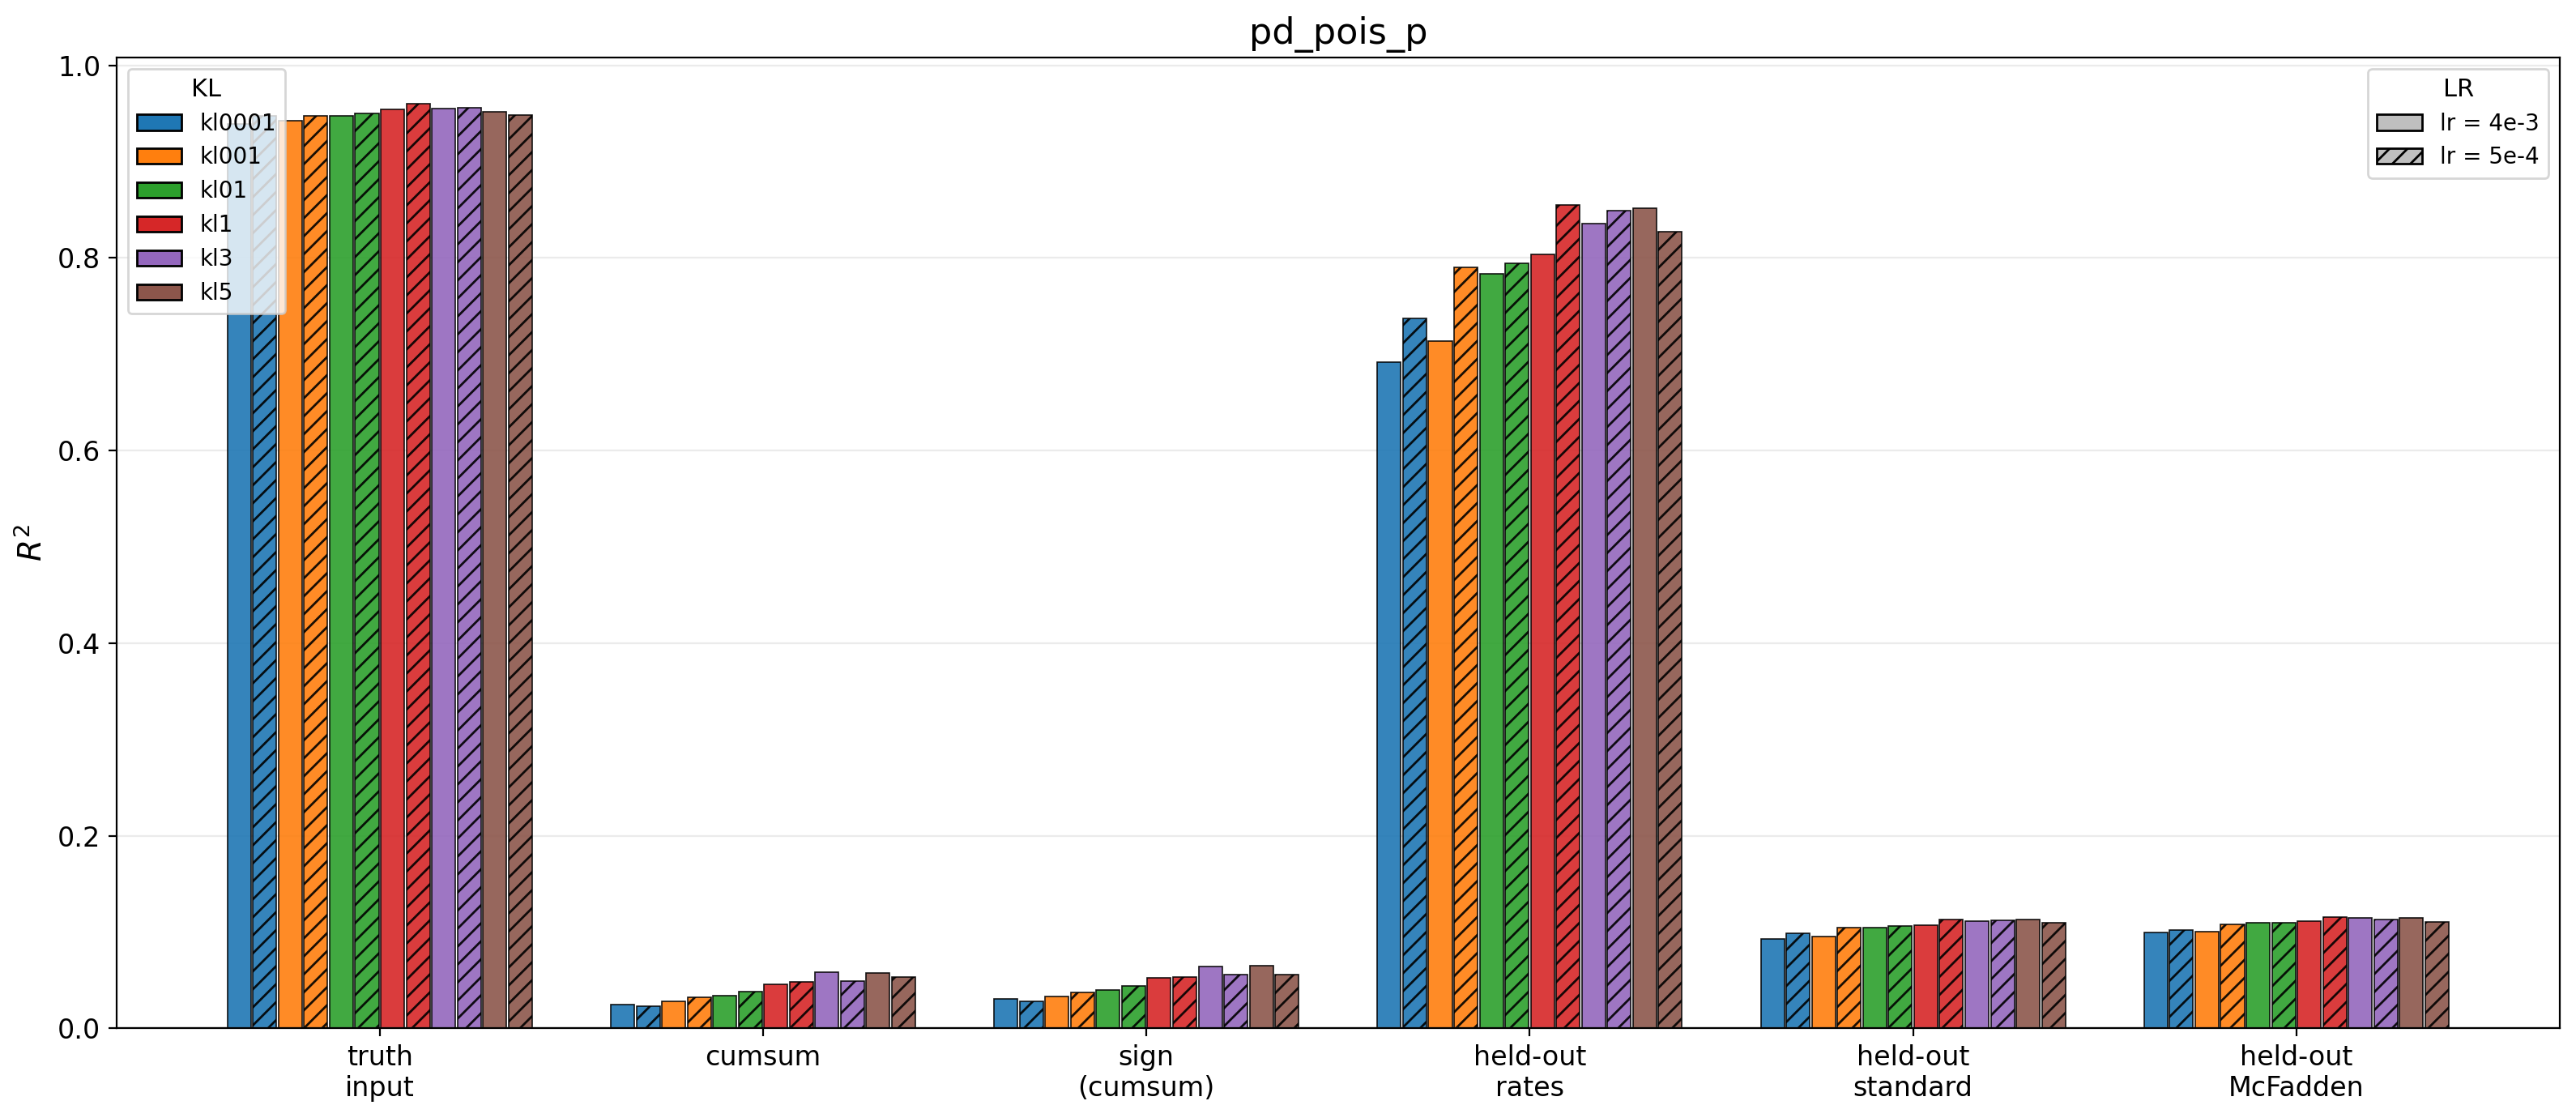

In [5]:
# pd_pois_runs/{d,p}/eval_summary.csv: metrics × KL (color) × LR (hatch)

import re

from matplotlib.patches import Patch
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

EVAL_ROOT = Path("..") / "pd_pois_runs"
CSV_SPECS = [
    ("d", "pd_pois_d"),
    ("p", "pd_pois_p"),
]
KL_ORDER = ["no_reg", "kl0001", "kl001", "kl01", "kl1", "kl3", "kl5"]
TARGET_SPECS = [
    ("truth-inp-decode-r2", "truth\ninput"),
    ("cumsum-decode-r2", "cumsum"),
    ("sign_cumsum-decode-r2", "sign\n(cumsum)"),
    ("message-p_to_d-decode-r2", "msg P→D\ndecode"),
    ("r2-held-out-rates", "held-out\nrates"),
    ("r2-held-out", "held-out\nstandard"),
    ("r2-held-out-mcfadden", "held-out\nMcFadden"),
]


def parse_kl(run_name: str) -> str:
    if "no_reg" in run_name:
        return "no_reg"
    m = re.search(r"_(kl\d+)(?:_lr)?_id", run_name)
    if m:
        return m.group(1)
    m = re.search(r"_(kl\d+)_", run_name)
    return m.group(1) if m else "unknown"


def parse_lr(run_name: str) -> bool:
    return bool(re.search(r"_lr(?:_id|_)", run_name) or run_name.endswith("_lr"))


for folder, title in CSV_SPECS:
    csv_path = EVAL_ROOT / folder / "eval_summary.csv"
    if not csv_path.is_file() or csv_path.stat().st_size == 0:
        print(f"SKIP missing/empty: {csv_path}")
        continue

    df = pd.read_csv(csv_path).copy()
    df["kl"] = df["run"].map(parse_kl)
    df["lr"] = df["run"].map(parse_lr)

    present_kl = [kl for kl in KL_ORDER if kl in set(df["kl"])]
    if not present_kl:
        print(f"SKIP {folder}: no recognized KL tags")
        continue

    # Only plot metrics that exist in this CSV
    target_specs = [(c, lab) for c, lab in TARGET_SPECS if c in df.columns]
    if not target_specs:
        print(f"SKIP {folder}: no target columns found")
        continue

    kl_colors = {kl: f"C{i}" for i, kl in enumerate(present_kl)}
    n_targets = len(target_specs)
    n_kl = len(present_kl)
    x = np.arange(n_targets)
    width = 0.8 / (n_kl * 2)

    fig, ax = plt.subplots(figsize=(16, 7), dpi=200)

    for j, kl in enumerate(present_kl):
        for k, (is_lr, hatch) in enumerate([(False, None), (True, "///")]):
            row = df[(df["kl"] == kl) & (df["lr"] == is_lr)]
            vals = []
            for col, _ in target_specs:
                if row.empty or col not in row.columns:
                    vals.append(np.nan)
                else:
                    vals.append(float(row.iloc[0][col]))
            slot = j * 2 + k
            offset = (slot - (n_kl * 2 - 1) / 2) * width
            ax.bar(
                x + offset,
                vals,
                width=width * 0.92,
                color=kl_colors[kl],
                hatch=hatch,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.9,
            )

    ax.set_xticks(x)
    ax.set_xticklabels([lab for _, lab in target_specs], fontsize=12, ha="center")
    ax.set_ylabel(r"$R^2$", fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.axhline(0, color="0.5", lw=0.8)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.8, alpha=0.8)

    kl_handles = [
        Patch(facecolor=kl_colors[kl], edgecolor="black", label=kl) for kl in present_kl
    ]
    style_handles = [
        Patch(facecolor="0.75", edgecolor="black", label="lr = 4e-3"),
        Patch(facecolor="0.75", edgecolor="black", hatch="///", label="lr = 5e-4"),
    ]
    leg1 = ax.legend(handles=kl_handles, title="KL", loc="upper left", fontsize=10, title_fontsize=11)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, title="LR", loc="upper right", fontsize=10, title_fontsize=11)

    fig.tight_layout()
    plt.show()



drop 4 mismatched-rate run(s):
  - full_model_10ms_40hz_kl0001_lr_id2607221038
  - full_model_10ms_40hz_kl001_lr_id2607221038
  - full_model_10ms_40hz_kl01_lr_id2607221038
  - full_model_10ms_40hz_kl1_lr_id2607221038
plotting ..\pd_pois_runs\pd_pois_full\eval_summary.csv (4 runs)


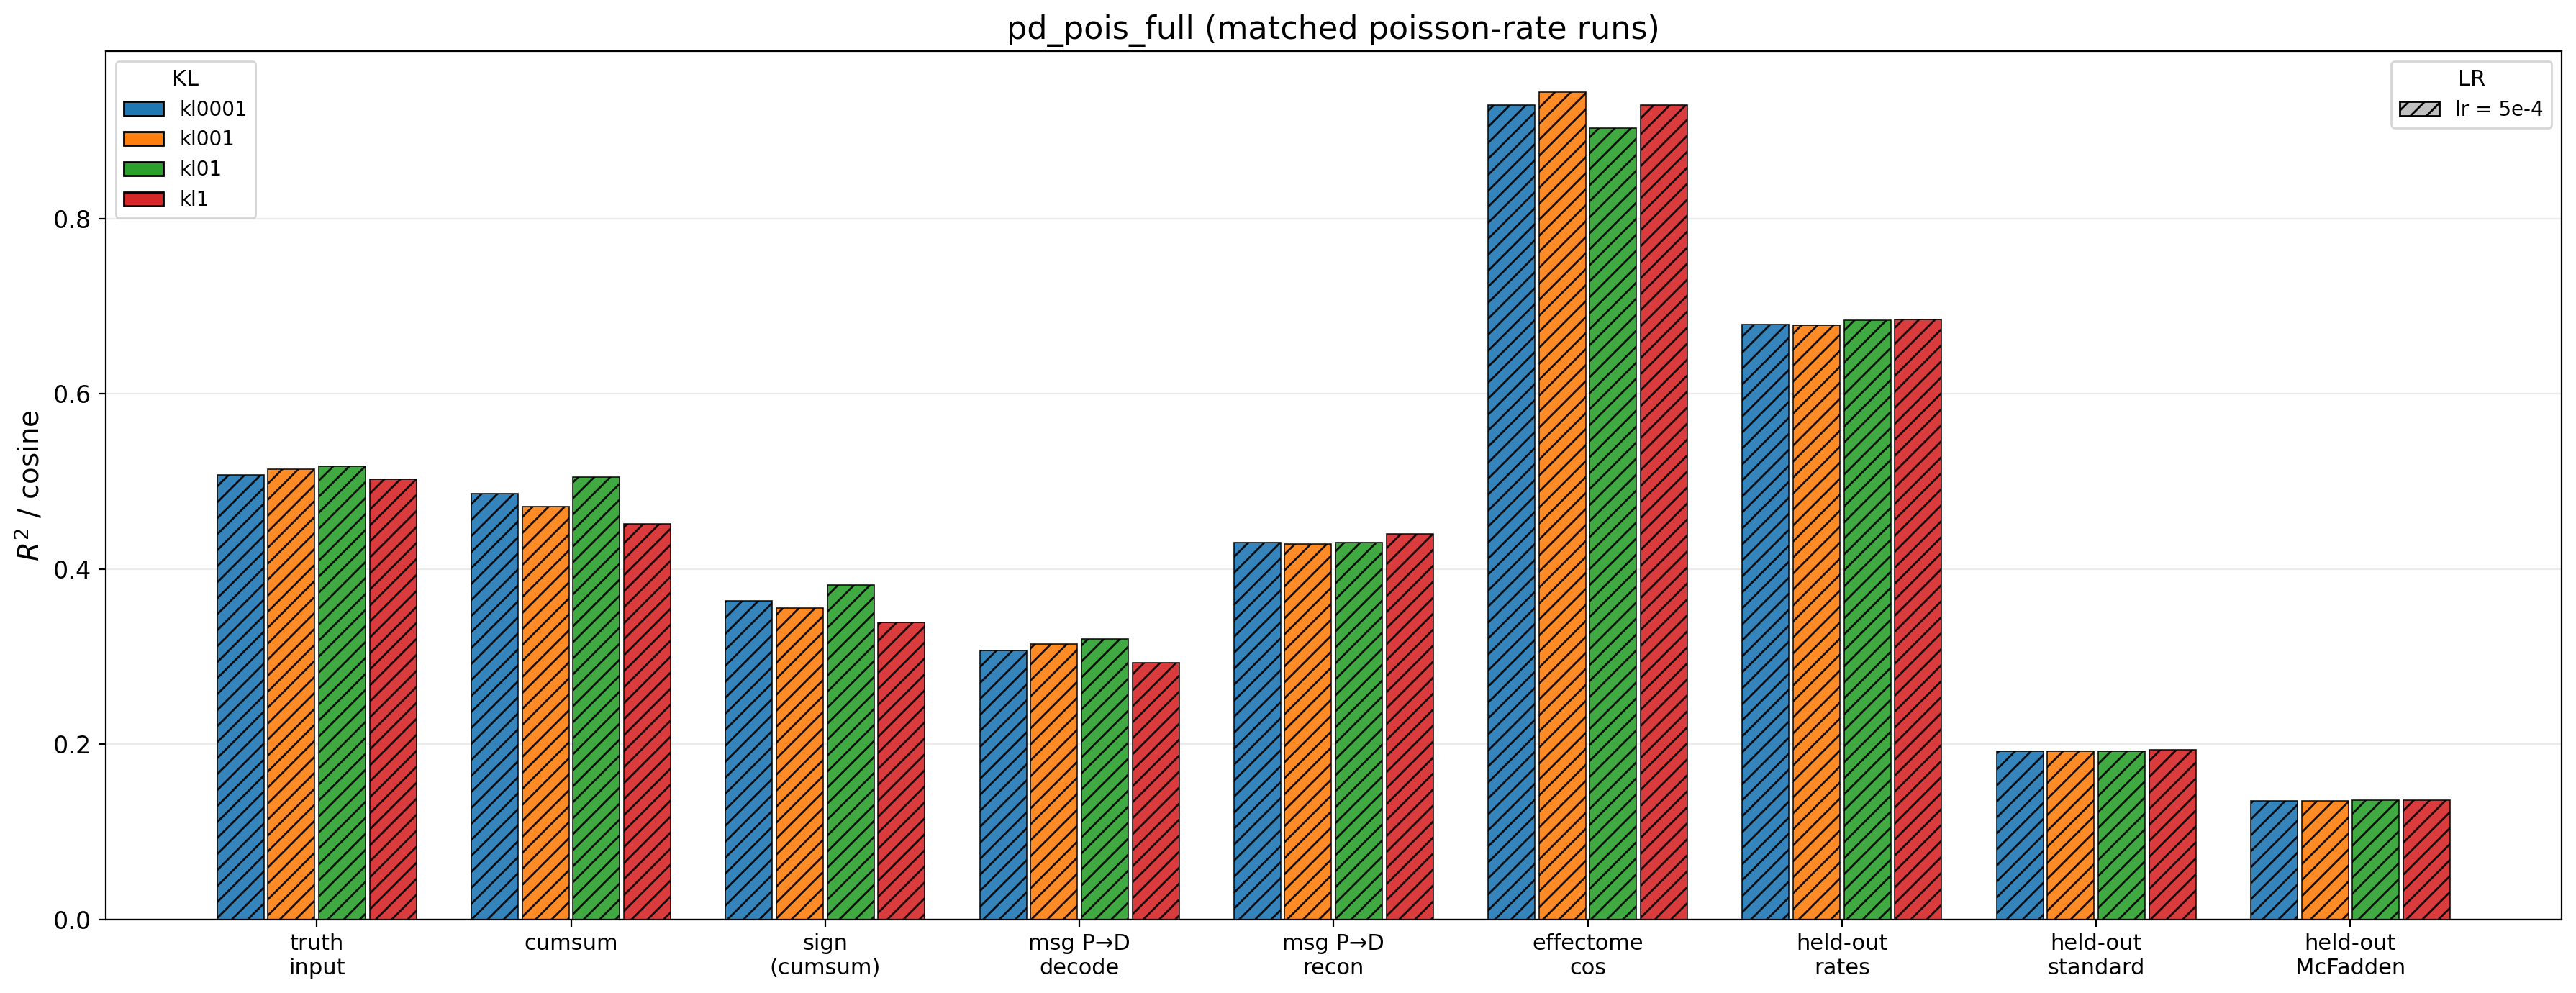

In [36]:
# pd_pois_full eval_summary: one plot, drop mismatched poisson-rate runs

import re

from matplotlib.patches import Patch
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Prefer the summary with decode columns; fall back to the other if needed
CSV_CANDIDATES = [
    Path("..") / "pd_pois_runs" / "pd_pois_full" / "eval_summary.csv",
    Path("..") / "pd_pois_runs" / "pd_pois_full_50ms" / "eval_summary.csv",
]
RATE_FLOOR = -1.0

KL_ORDER = ["no_reg", "kl0001", "kl001", "kl01", "kl1", "kl3", "kl5"]
TARGET_SPECS = [
    ("truth-inp-decode-r2-mean", "truth\ninput"),
    ("cumsum-decode-r2-mean", "cumsum"),
    ("sign_cumsum-decode-r2-mean", "sign\n(cumsum)"),
    ("message-p_to_d-decode-r2-mean", "msg P→D\ndecode"),
    ("message-p_to_d-r2", "msg P→D\nrecon"),
    ("effectome-cos-sim", "effectome\ncos"),
    ("r2-held-out-rates-mean", "held-out\nrates"),
    ("r2-held-out-mean", "held-out\nstandard"),
    ("r2-held-out-mcfadden-mean", "held-out\nMcFadden"),
]


def parse_kl(run_name: str) -> str:
    if "no_reg" in run_name:
        return "no_reg"
    m = re.search(r"_(kl\d+)(?:_lr)?_id", run_name)
    if m:
        return m.group(1)
    m = re.search(r"_(kl\d+)_", run_name)
    return m.group(1) if m else "unknown"


def parse_lr(run_name: str) -> bool:
    return bool(re.search(r"_lr(?:_id|_)", run_name) or run_name.endswith("_lr"))


csv_path = next((p for p in CSV_CANDIDATES if p.is_file() and p.stat().st_size > 0), None)
if csv_path is None:
    raise FileNotFoundError("No non-empty pd_pois_full eval_summary.csv found")

df = pd.read_csv(csv_path).copy()
df["kl"] = df["run"].map(parse_kl)
df["lr"] = df["run"].map(parse_lr)

if "r2-held-out-rates-mean" in df.columns:
    rates = pd.to_numeric(df["r2-held-out-rates-mean"], errors="coerce")
    keep = rates.isna() | (rates >= RATE_FLOOR)
    dropped = df.loc[~keep, "run"].tolist()
    if dropped:
        print(f"drop {len(dropped)} mismatched-rate run(s):")
        for r in dropped:
            print(f"  - {r}")
    df = df.loc[keep].reset_index(drop=True)

print(f"plotting {csv_path} ({len(df)} runs)")

present_kl = [kl for kl in KL_ORDER if kl in set(df["kl"])]
present_lr = sorted(df["lr"].unique().tolist())
kl_colors = {kl: f"C{i}" for i, kl in enumerate(present_kl)}

n_targets = len(TARGET_SPECS)
n_kl = len(present_kl)
n_lr = len(present_lr)
n_bars = max(n_kl * n_lr, 1)
x = np.arange(n_targets)
width = 0.8 / n_bars

fig, ax = plt.subplots(figsize=(18, 7), dpi=200)

for j, kl in enumerate(present_kl):
    for k, is_lr in enumerate(present_lr):
        row = df[(df["kl"] == kl) & (df["lr"] == is_lr)]
        vals = []
        for col, _ in TARGET_SPECS:
            if row.empty or col not in row.columns:
                vals.append(np.nan)
            else:
                vals.append(float(row.iloc[0][col]))
        slot = j * n_lr + k
        offset = (slot - (n_bars - 1) / 2) * width
        ax.bar(
            x + offset,
            vals,
            width=width * 0.92,
            color=kl_colors[kl],
            hatch="///" if is_lr else None,
            edgecolor="black",
            linewidth=0.6,
            alpha=0.9,
        )

ax.set_xticks(x)
ax.set_xticklabels([lab for _, lab in TARGET_SPECS], fontsize=11, ha="center")
ax.set_ylabel(r"$R^2$ / cosine", fontsize=14)
ax.set_title("pd_pois_full (matched poisson-rate runs)", fontsize=16)
ax.axhline(0, color="0.5", lw=0.8)
ax.tick_params(axis="y", labelsize=12)
ax.set_axisbelow(True)
ax.grid(axis="y", color="0.9", linewidth=0.8, alpha=0.8)

kl_handles = [Patch(facecolor=kl_colors[kl], edgecolor="black", label=kl) for kl in present_kl]
style_handles = []
if False in present_lr:
    style_handles.append(Patch(facecolor="0.75", edgecolor="black", label="lr = 4e-3"))
if True in present_lr:
    style_handles.append(Patch(facecolor="0.75", edgecolor="black", hatch="///", label="lr = 5e-4"))
leg1 = ax.legend(handles=kl_handles, title="KL", loc="upper left", fontsize=10, title_fontsize=11)
ax.add_artist(leg1)
if style_handles:
    ax.legend(handles=style_handles, title="LR", loc="upper right", fontsize=10, title_fontsize=11)

fig.tight_layout()
plt.show()



In [ ]:
# Visualize pd_pois_runs/full_seed0/eval_summary.csv (metrics × KL × LR), split by region.

import re

from matplotlib.patches import Patch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

CSV_PATH = Path("..") / "pd_pois_runs" / "full_seed0" / "eval_summary.csv"

KL_ORDER = ["no_reg", "kl0001", "kl001", "kl01", "kl1", "kl3", "kl5"]
TARGET_SPECS = [
    ("truth-inp-decode-r2", "truth\\ninput"),
    ("cumsum-decode-r2", "cumsum"),
    ("sign_cumsum-decode-r2", "sign\\n(cumsum)"),
    ("message-p_to_d-decode-r2", "msg P->D\\ndecode"),
    ("r2-held-out-rates", "held-out\\nrates"),
    ("r2-held-out", "held-out\\nstandard"),
    ("r2-held-out-mcfadden", "held-out\\nMcFadden"),
]


def parse_kl(run_name: str) -> str:
    if "no_reg" in run_name:
        return "no_reg"
    m = re.search(r"_(kl\d+)(?:_lr)?_id", run_name)
    if m:
        return m.group(1)
    m = re.search(r"_(kl\d+)_", run_name)
    return m.group(1) if m else "unknown"


def parse_lr(run_name: str) -> bool:
    # True for runs containing an explicit learning-rate tag
    return bool(re.search(r"_lr(?:_id|_)", run_name) or run_name.endswith("_lr"))


df = pd.read_csv(CSV_PATH).copy()
df["kl"] = df["run"].map(parse_kl)
df["lr"] = df["run"].map(parse_lr)

present_kls = [kl for kl in KL_ORDER if kl in set(df["kl"])]
if not present_kls:
    raise RuntimeError(f"No recognized KL tags in {CSV_PATH}")

kl_colors = {kl: f"C{i}" for i, kl in enumerate(present_kls)}

for region in sorted(df["region"].unique()):
    sub = df[df["region"] == region]

    sub_present_kls = [kl for kl in present_kls if kl in set(sub["kl"])]
    if not sub_present_kls:
        continue

    target_cols = [(c, lab) for c, lab in TARGET_SPECS if c in sub.columns]
    if not target_cols:
        continue

    n_targets = len(target_cols)
    n_kl = len(sub_present_kls)
    x = np.arange(n_targets)

    # two bars per KL (default vs lr)
    n_bars_per_target = n_kl * 2
    width = 0.8 / n_bars_per_target

    fig, ax = plt.subplots(figsize=(16, 7), dpi=200)

    for j, kl in enumerate(sub_present_kls):
        for k, (is_lr, hatch) in enumerate([(False, None), (True, "///")]):
            row = sub[(sub["kl"] == kl) & (sub["lr"] == is_lr)]
            vals = []
            for col, _ in target_cols:
                if row.empty or col not in row.columns:
                    vals.append(np.nan)
                else:
                    vals.append(float(row.iloc[0][col]))
            slot = j * 2 + k
            offset = (slot - (n_bars_per_target - 1) / 2) * width
            ax.bar(
                x + offset,
                vals,
                width=width * 0.92,
                color=kl_colors[kl],
                hatch=hatch,
                edgecolor="black",
                linewidth=0.6,
                alpha=0.9,
            )

    ax.set_xticks(x)
    ax.set_xticklabels([lab for _, lab in target_cols], fontsize=12, ha="center")
    ax.set_ylabel(r"$R^2$", fontsize=14)
    ax.set_title(f"pd_pois_runs/full_seed0 — region {region}", fontsize=16)
    ax.axhline(0, color="0.5", lw=0.8)
    ax.tick_params(axis="y", labelsize=12)
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="0.9", linewidth=0.8, alpha=0.8)

    kl_handles = [
        Patch(facecolor=kl_colors[kl], edgecolor="black", label=kl)
        for kl in sub_present_kls
    ]
    style_handles = [
        Patch(facecolor="0.75", edgecolor="black", label="lr=4e-3"),
        Patch(facecolor="0.75", edgecolor="black", hatch="///", label="lr=5e-4"),
    ]

    leg1 = ax.legend(handles=kl_handles, title="KL", loc="upper left", fontsize=10, title_fontsize=11)
    ax.add_artist(leg1)
    ax.legend(handles=style_handles, title="LR", loc="upper right", fontsize=10, title_fontsize=11)

    fig.tight_layout()
    plt.show()


